In [1]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
portfolio = {
    '종목명': ['삼성전자', 'SK하이닉스', '에이피알','RFHIC','삼성전기'],
    '종목코드': ['005930', '000660','278470','218410','009150'], 
    '수량': [29,6,9,38,5]
}

df = pd.DataFrame(portfolio)

In [ ]:
portfolio = {
    '종목명': ['TIGER 반도체TOP10', 'KODEX AI전력핵심설비', 'KODEX 증권','TIGER 코리아원자력','SOL 반도체 전공정','SOL 반도체 후공정','TIGER 은행고배당플러스 TOP10'],
    '종목코드': ['396500', '487240', '102970','0091P0','475300','475310','466940'], 
}

df = pd.DataFrame(portfolio)

In [3]:

portfolio = {
    '종목명': ['삼성전자', 'SK하이닉스', '에이피알','RFHIC','삼성전기'],
    '종목코드': ['005930', '000660','278470','218410','009150'], 
}

df = pd.DataFrame(portfolio)

def return_asset(ticker):

    # 오늘 날짜와 어제 날짜를 자동으로 계산
    today = datetime.today()
    yesterday = today - timedelta(days=7)

    # 계산된 날짜를 그대로 넣어줍니다.
    data = fdr.DataReader(ticker, yesterday, today)['Close']

    returns = (data.iloc[-1]/data.iloc[-5]-1)*100

    return returns

In [9]:
df['수익률_1D'] = df['종목코드'].apply(return_asset).round(2)

In [8]:
df = df.drop(columns=['수익률_1D'])

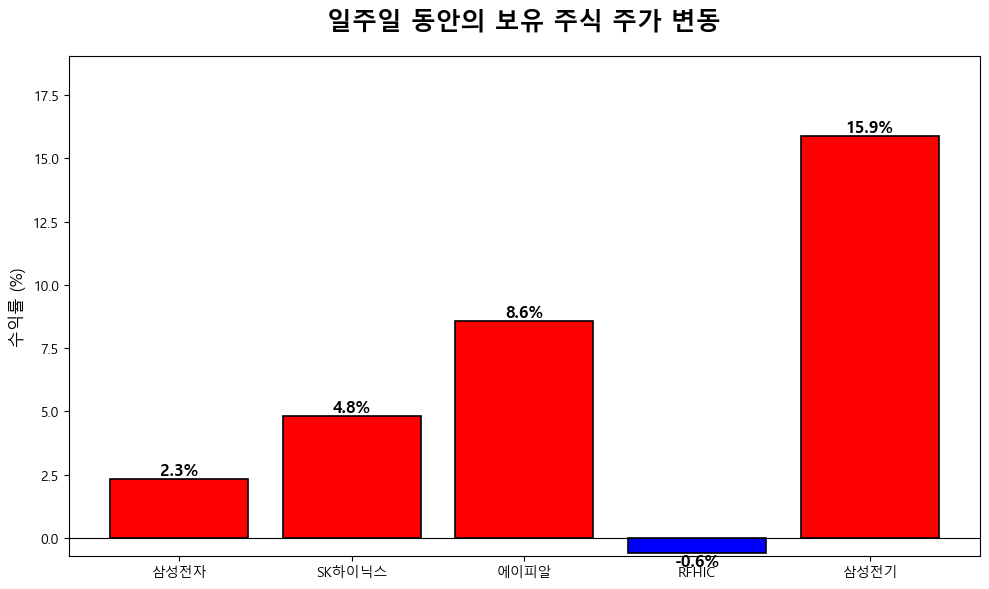

In [11]:
import platform


# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
    
# 마이너스 기호 깨짐 방지 (이 부분이 중요합니다)
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 3. 막대그래프 그리기
# 수익률에 따라 색상을 다르게 주면 더 직관적입니다 (양수: 빨강, 음수: 파랑)
colors = ['red' if x >= 0 else 'blue' for x in df['수익률_1D']]

bars = plt.bar(
    df['종목명'], 
    df['수익률_1D'], 
    color=colors,     # 동적 색상 적용
    edgecolor='black', 
    linewidth=1.2
)

# 4. 막대 위/아래에 정확한 수치(%) 표시하기
for bar in bars:
    height = bar.get_height()
    # 양수면 막대 위(bottom), 음수면 막대 아래(top)에 텍스트 배치
    va = 'bottom' if height >= 0 else 'top'
    
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height, 
        f'{height:.1f}%', 
        ha='center', 
        va=va, 
        fontsize=12,
        fontweight='bold'
    )

# 5. 축 라벨 및 제목 설정
plt.title('일주일 동안의 보유 주식 주가 변동', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('수익률 (%)', fontsize=12)

# 0선(기준선)을 진하게 그어 마이너스와 플러스를 구분합니다.
plt.axhline(0, color='black', linewidth=0.8)

# 6. y축 범위 자동 설정 (가장 중요!)
# 마이너스 최소값과 플러스 최대값을 찾아 여백을 줍니다.
y_min = df['수익률_1D'].min()
y_max = df['수익률_1D'].max()

# 위아래로 20% 정도 여백 확보
plt.ylim(y_min * 1.2 if y_min < 0 else -1, y_max * 1.2 if y_max > 0 else 1)

plt.tight_layout()
plt.show()